# Player Touch Maps\n\nUses the same WhoScored scraping setup as `model_template.ipynb` / `whoscored_team_colection.ipynb`, via the reusable `player_touchmaps.py` module. League-wide: `collect_league_events` scrapes a full league season (every club, every player), so any player in the league can be checked, not just one team's squad.\n\nThis notebook is for looking at one player interactively. For batch jobs that render + save maps for **every player in a league season** in one run (scrapes the full season first, then renders — takes a while, safe to interrupt and resume), run one of these as a script instead:\n\n```\npython player_touchmaps.py   # final-third touch map + average-position heatmap -> player_maps/\npython touch_maps.py         # full-pitch touch map (same style, whole pitch)   -> touch_maps/\n```\n\nBoth call into `player_touchmaps.py`'s `build_league_*` functions (`build_league_player_maps` / `build_league_touch_maps`), writing PNGs to `{player_maps,touch_maps}/ENG-Premier_League_2025/{team}/{player}_*.png` plus a `summary.csv` of what was written/skipped/errored. Call the `build_league_*` functions directly for a different league/season.\n\nThe interactive views below:\n\n1. **Final third touch map** — every touch in the attacking third across the whole season.\n2. **Average position heatmap** — where a player spends their time, either in a single game or averaged across the season."

In [1]:
import matplotlib.pyplot as plt

from player_touchmaps import (
    collect_league_events,
    load_season_events,
    final_third_touch_map,
    avg_position_heatmap,
    player_events,
)

[08/25/26 20:20:44] INFO     No custom team name replacements found. You can configure these in       ]8;id=4116620;file:///home/caff/Documents/footy_analysis/.venv/lib/python3.12/site-packages/soccerdata/_config.py\_config.py]8;;\:]8;id=4116621;file:///home/caff/Documents/footy_analysis/.venv/lib/python3.12/site-packages/soccerdata/_config.py#92\92]8;;\
                             /home/caff/soccerdata/config/teamname_replacements.json.                              

                    INFO     No custom league dict found. You can configure additional leagues in    ]8;id=4116627;file:///home/caff/Documents/footy_analysis/.venv/lib/python3.12/site-packages/soccerdata/_config.py\_config.py]8;;\:]8;id=4116628;file:///home/caff/Documents/footy_analysis/.venv/lib/python3.12/site-packages/soccerdata/_config.py#190\190]8;;\
                             /home/caff/soccerdata/config/league_dict.json.                                        

## Config\n\n`collect_league_events(league=LEAGUE, season=SEASON)` with `team=None` scrapes the *entire* league schedule (~380 games for a 20-team division), caching each game to `save_dir` so re-runs don't re-scrape anything — safe to interrupt and resume. Pass `team=` to restrict this to one club's fixtures instead (fast, but only that club's opponents show up, and only in the games they actually played against it — that's what `utd_games/` is).\n\n`load_season_events` just reads whatever's already cached on disk, offline, no scraping."

In [2]:
PLAYER = "Bruno Fernandes"
TEAM = "Man Utd"  # None also works once season_df has full league coverage
LEAGUE = "ENG-Premier League"
SEASON = 2026

# Full league (any player, any club) — first run scrapes ~380 games, then it's all cached:
# season_df = collect_league_events(league=LEAGUE, season=SEASON)

# Faster, narrower alternative — only TEAM's own fixtures:
# season_df = collect_league_events(league=LEAGUE, season=SEASON, team=TEAM, save_dir="utd_games")

season_df = load_season_events("utd_games")  # offline: reuse everything already cached

player_events(season_df, PLAYER, team=TEAM)["game_id"].nunique()

18

### Name collisions\n\nOnce `season_df` covers the whole league, a loose partial name can match more than one player. `player_events` (and both plot functions, which call it internally) raise in that case rather than silently mixing two players' touches — disambiguate with a fuller name or `team=`."

In [3]:
try:
    player_events(season_df, "Fernandes")  # ambiguous without team=
except ValueError as e:
    print(e)

'Fernandes' matches multiple players: Bruno Fernandes (Man Utd), Mateus Fernandes (West Ham). Pass a fuller name or `team=` to disambiguate.


In [4]:
from pyfonts import load_google_font

font = load_google_font("DotGothic16")
if hasattr(font, "_pyfonts_provider_metadata"):
    del font._pyfonts_provider_metadata

## Final third touch map — full season"

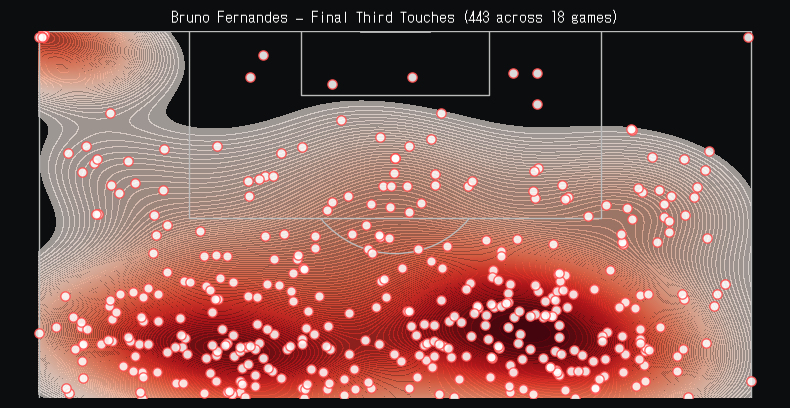

In [5]:
ax = final_third_touch_map(season_df, PLAYER, team=TEAM, font=font)
plt.show()

## Average position heatmap — full season vs. a single game"

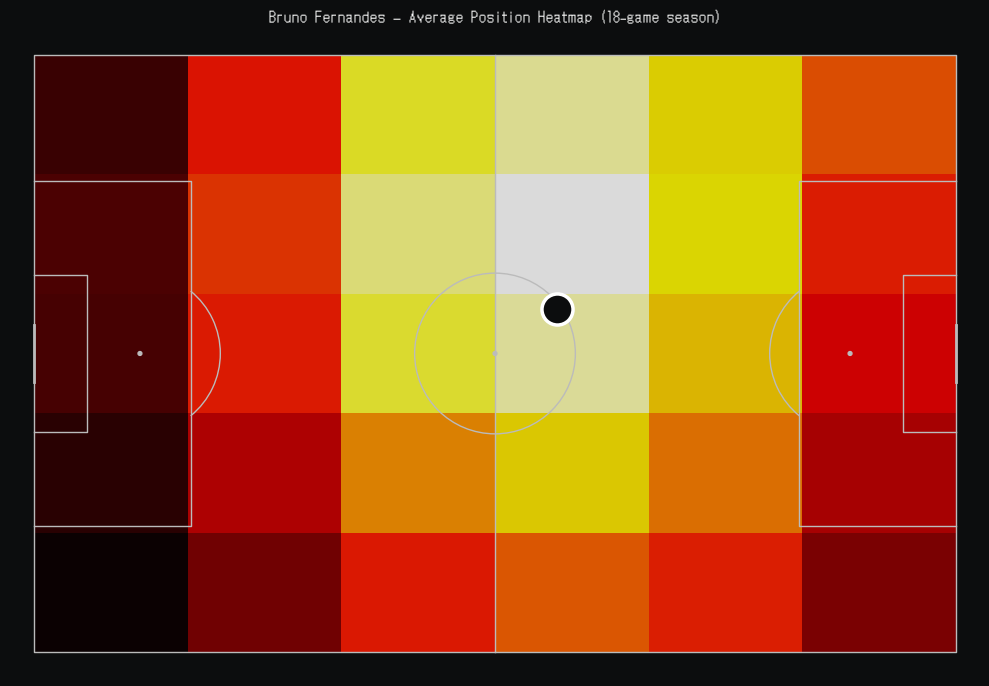

In [6]:
ax = avg_position_heatmap(season_df, PLAYER, team=TEAM, font=font)
plt.show()

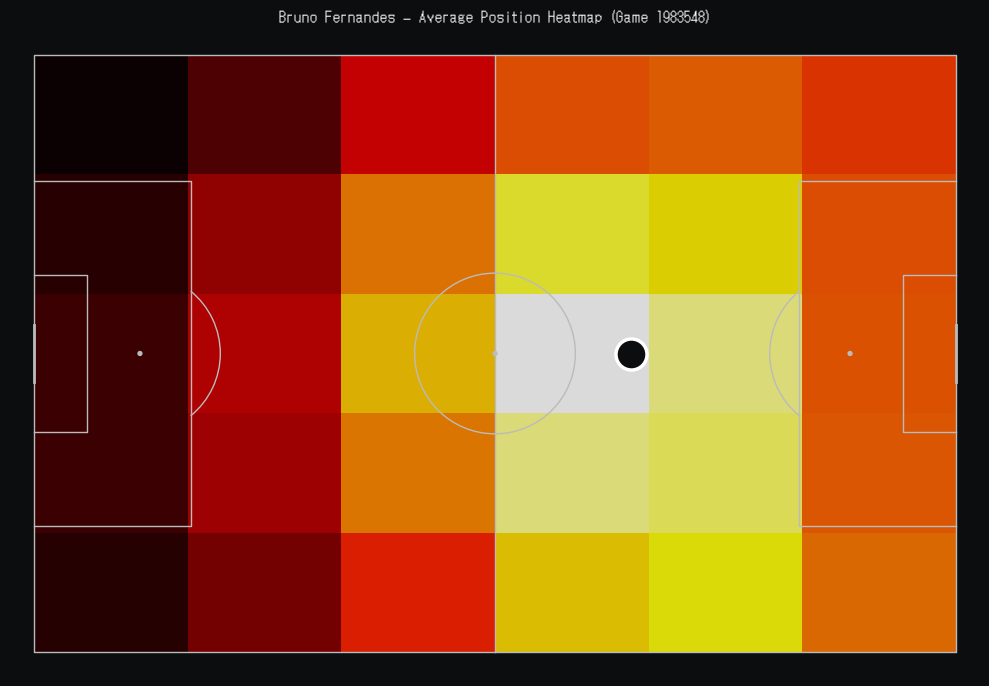

In [7]:
game_id = player_events(season_df, PLAYER, team=TEAM)["game_id"].iloc[-1]

ax = avg_position_heatmap(season_df, PLAYER, team=TEAM, game_id=int(game_id), font=font)
plt.show()